### **Abstract: Noise Accumulation & DSALT**

This experiment evaluates **DenseGPT** (standard Transformer) against the proposed **DSALT** (Dynamic Sparse Attention with Landmark Tokens) framework.  
The core hypothesis posits that dense attention introduces systematic noise ($\eta_i$) due to the *strict positivity* of the softmax operation, which accelerates **rank collapse** and leads to the progressive corruption of token representations in long contexts.

By employing an adaptive local window $w(i)$ and a set of globally informative landmark tokens $\mathcal{L}$, **DSALT** aims to mitigate noise accumulation at its source and preserve the rank of the attention matrix, while simultaneously optimizing computational complexity from $\mathcal{O}(n^2 d)$ to $\mathcal{O}(n(w+k)d)$.


### **Key Takeaway for the Experiment**

If the theory holds, as training progresses through the 2,000 steps, the **DSALT** model should maintain a higher **Effective Rank** or **Feature Diversity** compared to the **Dense** model, even if the initial **Loss** curves appear similar.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TUO_UTENTE/NOME_REPO/blob/main/dsalt.ipynb)

In [1]:
!pip install datasets transformers accelerate -q

In [2]:
import os, math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from transformers import GPT2TokenizerFast
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

CFG = {
    "seq_len": 1024,
    "d_model": 512,
    "n_heads": 8,
    "n_layers": 6,
    "batch_size": 16,
    "grad_accum": 4,
    "max_steps": 5500,
    "warmup_steps": 500,
    "lr": 3e-4,
    "weight_decay": 0.1,
    "grad_clip": 1.0,
    "val_every": 500,
    "log_every": 100,
    "w_min": 64,
    "w_max": 512,
    "k_landmarks": 8,
    "train_split": "train[:10%]",
    "val_split": "validation[:80%]"
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | GPUs: {torch.cuda.device_count()}")

Device: cuda | GPUs: 2


## Dataset

In [ ]:
tokenizer = GPT2TokenizerFast.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token
VOCAB_SIZE = tokenizer.vocab_size

class WikiDataset(Dataset):
    def __init__(self, split, seq_len):
        raw = load_dataset("wikitext", "wikitext-103-raw-v1", split=split)
        ids = []
        for row in raw:
            if row["text"].strip():
                enc = tokenizer(row["text"], truncation=False, padding=False)["input_ids"]
                ids.extend(enc)
        n = (len(ids) // seq_len) * seq_len
        self.data = torch.tensor(ids[:n], dtype=torch.long).view(-1, seq_len)
        print(f"Split={split} | Sequences: {len(self.data)} | Tokens: {len(ids[:n]):,}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        seq = self.data[i]
        return seq[:-1], seq[1:]

train_ds = WikiDataset(CFG["train_split"], CFG["seq_len"])
val_ds = WikiDataset(CFG["val_split"],   CFG["seq_len"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=2, pin_memory=True, drop_last=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

## Models

In [4]:
# ── Dense Attention ──────────────────────────────────────────────────────────
class DenseAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        self._last_P = None

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.d_head)
        q, k, v = qkv.unbind(2) 
        q = q.transpose(1, 2)     
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        scale = self.d_head ** -0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale
        causal = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        scores = scores.masked_fill(~causal, float('-inf'))
        P = torch.softmax(scores, dim=-1) 
        self._last_P = P.detach()
        out = torch.matmul(P, v)      
        out = out.transpose(1, 2).reshape(B, T, C)
        return self.proj(out)


# ── DSALT Attention ───────────────────────────────────────────────────────────

class DSALTAttention(nn.Module):
    def __init__(self, d_model, n_heads, w_min, w_max, k_landmarks):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.w_min = w_min
        self.w_max = w_max
        self.k_landmarks = k_landmarks
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        self.w_gate = nn.Linear(d_model, 1, bias=False)
        self._last_P = None

    def _build_mask(self, x):
        B, T, C = x.shape
        device  = x.device

        gate = torch.sigmoid(self.w_gate(x.detach())).squeeze(-1)
        w_avg = gate.mean(0)
        w = (self.w_min + (w_avg * (self.w_max - self.w_min))).long().clamp(self.w_min, self.w_max)

        rows = torch.arange(T, device=device)
        cols = torch.arange(T, device=device)
        local_mask = (cols.unsqueeze(0) <= rows.unsqueeze(1)) & \
                     (cols.unsqueeze(0) >= (rows - w).unsqueeze(1))

        if self.k_landmarks > 0:
            norms = x.detach().norm(dim=-1).mean(0)
            outside_end = (rows - w).clamp(min=0)
            cand_mask = cols.unsqueeze(0) < outside_end.unsqueeze(1)
            scores_land = norms.unsqueeze(0).expand(T, T).clone()
            scores_land[~cand_mask] = -float('inf')
            k = self.k_landmarks
            topk_vals, topk_idx = torch.topk(scores_land, k=min(k, T), dim=1)
            valid = topk_vals > -float('inf')
            land_mask = torch.zeros(T, T, device=device, dtype=torch.bool)
            land_mask.scatter_(1, topk_idx.clamp(min=0), valid)
        else:
            land_mask = torch.zeros(T, T, device=device, dtype=torch.bool)

        return local_mask | land_mask

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.d_head)
        q, k, v = qkv.unbind(2)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        scale  = self.d_head ** -0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale
        mask   = self._build_mask(x)
        scores = scores.masked_fill(~mask.unsqueeze(0).unsqueeze(0), float('-inf'))
        P  = torch.softmax(scores, dim=-1)
        self._last_P = P.detach()
        out = torch.matmul(P, v)
        out = out.transpose(1, 2).reshape(B, T, C)
        return self.proj(out)

# ── Shared Transformer blocks ─────────────────────────────────────────────────

class Block(nn.Module):
    def __init__(self, d_model, n_heads, attn_module):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = attn_module
        self.ln2  = nn.LayerNorm(d_model)
        self.mlp  = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class GPTModel(nn.Module):
    def __init__(self, vocab_size, cfg, use_dsalt=False):
        super().__init__()
        d, h = cfg["d_model"], cfg["n_heads"]
        self.tok_emb = nn.Embedding(vocab_size, d)
        self.pos_emb = nn.Embedding(cfg["seq_len"], d)
        self.blocks  = nn.ModuleList([
            Block(d, h,
                  DSALTAttention(d, h, cfg["w_min"], cfg["w_max"], cfg["k_landmarks"])
                  if use_dsalt else
                  DenseAttention(d, h))
            for _ in range(cfg["n_layers"])
        ])
        self.ln_f  = nn.LayerNorm(d)
        self.head  = nn.Linear(d, vocab_size, bias=False)
        self.tok_emb.weight = self.head.weight

    def forward(self, idx):
        B, T = idx.shape
        pos  = torch.arange(T, device=idx.device)
        x    = self.tok_emb(idx) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        return self.head(self.ln_f(x))


dense_model = GPTModel(VOCAB_SIZE, CFG, use_dsalt=False).to(device)
dsalt_model = GPTModel(VOCAB_SIZE, CFG, use_dsalt=True).to(device)

if torch.cuda.device_count() > 1:
    dense_model = nn.DataParallel(dense_model)
    dsalt_model = nn.DataParallel(dsalt_model)

n_params = sum(p.numel() for p in dense_model.parameters() if p.requires_grad)

## Training

In [5]:
def get_lr(step, d_model, warmup_steps):
    """Noam scheduler (Vaswani et al. 2017)"""
    step  = max(step, 1)
    scale = d_model ** (-0.5)
    arg1  = step ** (-0.5)
    arg2  = step * (max(warmup_steps, 1) ** (-1.5))
    return scale * min(arg1, arg2)

def train_model(model, name, train_loader, val_loader, cfg):
    opt = torch.optim.AdamW(
        model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
    )
    def lr_lambda(step):
        if step < cfg["warmup_steps"]:
            return step / cfg["warmup_steps"]
        progress = (step - cfg["warmup_steps"]) / max(1, cfg["max_steps"] - cfg["warmup_steps"])
        return max(0.1, 0.5 * (1 + math.cos(math.pi * progress)))
    scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    scaler    = torch.amp.GradScaler('cuda')

    history = {k: [] for k in
               ["train_loss","sigma2","eff_rank","res_norm",
                "attn_entropy","noise_norm","step_time","val_ppl", "layerwise",]}

    step = 0
    loss_accum = 0.0
    t0 = time.time()
    opt.zero_grad()

    loader_iter = iter(train_loader)

    while step < cfg["max_steps"]:
        for acc_step in range(cfg["grad_accum"]):
            try:
                x, y = next(loader_iter)
            except StopIteration:
                loader_iter = iter(train_loader)
                x, y = next(loader_iter)
            x, y = x.to(device), y.to(device)

            with torch.amp.autocast('cuda'):
                logits = model(x)
                loss   = F.cross_entropy(
                    logits.reshape(-1, logits.size(-1)), y.reshape(-1)
                ) / cfg["grad_accum"]

            scaler.scale(loss).backward()
            loss_accum += loss.item()

        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
        scaler.step(opt)
        scaler.update()
        scheduler.step()
        opt.zero_grad()
        step += 1

        if step % cfg["log_every"] == 0:
            elapsed   = time.time() - t0
            its       = cfg["log_every"] / elapsed
            metrics   = compute_metrics(model, x)
            lr_now    = scheduler.get_last_lr()[0]
            print(
                f"[{name}] step {step:5d} | loss {loss_accum:.4f} | "
                f"σ₂ {metrics['sigma2']:.7f} | rank {metrics['eff_rank']:.1f} | "
                f"res {metrics['res_norm']:.4f} | entropy {metrics['attn_entropy']:.4f} | "
                f"noise {metrics['noise_norm']:.4f} | lr {lr_now:.2e} | {its:.1f} it/s"
            )
            sample = x[:1]
            history["layerwise"].append(layerwise_collapse(model, sample, device))
            history["train_loss"].append(loss_accum)
            history["sigma2"].append(metrics["sigma2"])
            history["eff_rank"].append(metrics["eff_rank"])
            history["res_norm"].append(metrics["res_norm"])
            history["attn_entropy"].append(metrics["attn_entropy"])
            history["noise_norm"].append(metrics["noise_norm"])
            history["step_time"].append(elapsed / cfg["log_every"])
            loss_accum = 0.0
            t0         = time.time()

        if step % cfg["val_every"] == 0:
            _, ppl = evaluate(model, val_loader, device)
            history["val_ppl"].append(ppl)
            print(f"[{name}] *** val ppl {ppl:.2f} ***")

    return history


@torch.no_grad()
def compute_metrics(model, x):
    """
    x: (B, T) token ids
    Returns dict with σ₂, eff_rank, res_norm, attn_entropy, noise_norm
    measured on the LAST layer's attention matrix P (T, T).
    """
    m = model.module if isinstance(model, nn.DataParallel) else model
    m.eval()
    _ = m(x)

    P = m.blocks[-1].attn._last_P.float()
    P_avg = P.mean(dim=(0, 1))

    sv     = torch.linalg.svdvals(P_avg)
    sigma2 = sv[1].item() if sv.shape[0] > 1 else 0.0

    sv_norm  = sv / (sv.sum() + 1e-9)
    eff_rank = torch.exp(-(sv_norm * (sv_norm + 1e-9).log()).sum()).item()

    B, T = x.shape
    pos  = torch.arange(T, device=x.device)
    h = m.tok_emb(x) + m.pos_emb(pos)
    for block in m.blocks:
        h = block(h)
    x_mean  = h.mean(dim=1, keepdim=True)
    res = h - x_mean
    res_norm = (res.norm() / (h.norm() + 1e-9)).item()

    P_safe = P.clamp(min=1e-9)
    entropy = -(P_safe * P_safe.log()).sum(dim=-1).mean().item()

    rows = torch.arange(P.shape[2], device=P.device)
    cols = torch.arange(P.shape[3], device=P.device)
    local = (cols.unsqueeze(0) <= rows.unsqueeze(1)) & \
            (cols.unsqueeze(0) >= (rows - 64).unsqueeze(1))
    noise_mask = ~local
    noise_norm = (P * noise_mask.unsqueeze(0).unsqueeze(0)).sum(dim=-1).mean().item()

    m.train()
    return {
        "sigma2":       sigma2,
        "eff_rank":     eff_rank,
        "res_norm":     res_norm,
        "attn_entropy": entropy,
        "noise_norm":   noise_norm,
    }


@torch.no_grad()
def layerwise_collapse(model, x, device):
    m = model.module if isinstance(model, nn.DataParallel) else model
    m.eval()
    B, T = x.shape
    pos = torch.arange(T, device=device)
    h = m.tok_emb(x) + m.pos_emb(pos)
    h0_norm = h.norm().item()
    norms = []
    for block in m.blocks:
        h = block(h)
        x_mean = h.mean(dim=1, keepdim=True)
        res = (h - x_mean).norm() / (h0_norm + 1e-9)
        norms.append(res.item())
    m.train()
    return norms

@torch.no_grad()
def evaluate(model, val_loader, device):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        total_loss   += loss.item() * y.numel()
        total_tokens += y.numel()
    model.train()
    avg_loss = total_loss / total_tokens
    return avg_loss, math.exp(avg_loss)


@torch.no_grad()
def sliding_window_eval(model, tokenizer, text, seq_len, stride, device):
    """
    Valuta PPL su sequenze più lunghe di seq_len usando una sliding window.
    Metodo standard (Press et al.) per valutare LM su testi lunghi.
    """
    model.eval()
    ids = tokenizer(text, return_tensors="pt")["input_ids"].squeeze()
    n  = len(ids)
    nlls = []
    prev_end = 0

    for begin in range(0, n - seq_len, stride):
        end     = min(begin + seq_len, n)
        chunk   = ids[begin:end].unsqueeze(0).to(device)
        target  = chunk.clone()
        target_start = max(0, prev_end - begin)
        target[:, :target_start] = -100

        with torch.amp.autocast('cuda'):
            logits = model(chunk[:, :-1])
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                target[:, 1:].reshape(-1),
                ignore_index=-100, reduction='sum'
            )
        n_valid = (target[:, 1:] != -100).sum().item()
        if n_valid > 0:
            nlls.append(loss.item() / n_valid)
        prev_end = end

    ppl = math.exp(np.mean(nlls))
    print(f"Sliding Window PPL (stride={stride}): {ppl:.2f}")
    return ppl


@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=200, temperature=0.8,
             top_k=50, device=device):
    model.eval()
    seq_len = CFG["seq_len"]
    ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)
    for _ in range(max_new_tokens):
        ids_cond = ids[:, -seq_len:]
        with torch.amp.autocast('cuda'):
            logits = model(ids_cond)
        logits = logits[:, -1, :] / temperature
        if top_k > 0:
            vals, _ = torch.topk(logits, top_k)
            logits[logits < vals[:, -1:]] = float('-inf')
        probs   = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        ids = torch.cat([ids, next_id], dim=1)
    return tokenizer.decode(ids[0].tolist(), skip_special_tokens=True)

In [6]:
set_seed(42)
dense_model = GPTModel(VOCAB_SIZE, CFG, use_dsalt=False).to(device)
set_seed(42)
dsalt_model = GPTModel(VOCAB_SIZE, CFG, use_dsalt=True).to(device)

if torch.cuda.device_count() > 1:
    dense_model = nn.DataParallel(dense_model)
    dsalt_model = nn.DataParallel(dsalt_model)

n_params_dense = sum(p.numel() for p in dense_model.parameters() if p.requires_grad)
n_params_dsalt = sum(p.numel() for p in dsalt_model.parameters() if p.requires_grad)
print(f"Params Dense: {n_params_dense:,}")
print(f"Params DSALT: {n_params_dsalt:,}")

Params Dense: 45,158,912
Params DSALT: 45,161,984


In [7]:
print("\n========== TRAINING DENSE ==========")
dense_history = train_model(dense_model, "dense", train_loader, val_loader, CFG)


========== TRAINING DENSE ==========
[dense] step   100 | loss 970.6274 | σ₂ 1.2950268 | rank 102.5 | res 0.1508 | entropy 5.9314 | noise 0.7623 | lr 6.00e-05 | 0.4 it/s
[dense] step   200 | loss 761.1274 | σ₂ 1.2937627 | rank 102.5 | res 0.0871 | entropy 5.9337 | noise 0.7621 | lr 1.20e-04 | 0.4 it/s
[dense] step   300 | loss 746.3789 | σ₂ 1.2936721 | rank 102.5 | res 0.0765 | entropy 5.9339 | noise 0.7621 | lr 1.80e-04 | 0.4 it/s
[dense] step   400 | loss 746.1382 | σ₂ 1.2939098 | rank 102.6 | res 0.0684 | entropy 5.9339 | noise 0.7620 | lr 2.40e-04 | 0.4 it/s
[dense] step   500 | loss 746.9228 | σ₂ 1.2951621 | rank 102.6 | res 0.0693 | entropy 5.9332 | noise 0.7620 | lr 3.00e-04 | 0.4 it/s
[dense] *** val ppl 1709.14 ***
[dense] step   600 | loss 746.1305 | σ₂ 1.3286139 | rank 96.2 | res 0.2468 | entropy 5.6977 | noise 0.7701 | lr 3.00e-04 | 0.4 it/s
[dense] step   700 | loss 717.3859 | σ₂ 1.4661086 | rank 127.6 | res 0.6097 | entropy 4.2951 | noise 0.7634 | lr 2.99e-04 | 0.4 it/s


In [8]:
import gc

import json
with open('/kaggle/working/dense_history.json', 'w') as f:
    json.dump(dense_history, f)

m = dense_model.module if isinstance(dense_model, nn.DataParallel) else dense_model
torch.save(m.state_dict(), '/kaggle/working/dense_model.pt')

del dense_model
gc.collect()
torch.cuda.empty_cache()

for i in range(torch.cuda.device_count()):
    allocated = torch.cuda.memory_allocated(i) / 1e9
    reserved  = torch.cuda.memory_reserved(i) / 1e9
    print(f"GPU {i}: allocated {allocated:.2f}GB | reserved {reserved:.2f}GB")

GPU 0: allocated 0.59GB | reserved 0.89GB
GPU 1: allocated 0.02GB | reserved 0.05GB


In [9]:
print("\n========== TRAINING DSALT ==========")
dsalt_history = train_model(dsalt_model, "dsalt", train_loader, val_loader, CFG)


========== TRAINING DSALT ==========
[dsalt] step   100 | loss 974.3766 | σ₂ 1.2007457 | rank 149.9 | res 0.1506 | entropy 5.3492 | noise 0.6729 | lr 6.00e-05 | 0.4 it/s
[dsalt] step   200 | loss 761.9647 | σ₂ 1.1927941 | rank 151.8 | res 0.0844 | entropy 5.3211 | noise 0.6654 | lr 1.20e-04 | 0.4 it/s
[dsalt] step   300 | loss 746.0955 | σ₂ 1.1954416 | rank 148.5 | res 0.0737 | entropy 5.3520 | noise 0.6728 | lr 1.80e-04 | 0.4 it/s
[dsalt] step   400 | loss 746.5392 | σ₂ 1.1923037 | rank 152.6 | res 0.0667 | entropy 5.3059 | noise 0.6615 | lr 2.40e-04 | 0.4 it/s
[dsalt] step   500 | loss 746.9898 | σ₂ 1.1970894 | rank 149.2 | res 0.0672 | entropy 5.3439 | noise 0.6708 | lr 3.00e-04 | 0.4 it/s
[dsalt] *** val ppl 1715.94 ***
[dsalt] step   600 | loss 746.2128 | σ₂ 1.1915288 | rank 153.3 | res 0.1186 | entropy 5.3131 | noise 0.6634 | lr 3.00e-04 | 0.4 it/s
[dsalt] step   700 | loss 718.5715 | σ₂ 1.2387869 | rank 198.2 | res 0.5372 | entropy 4.6143 | noise 0.6689 | lr 2.99e-04 | 0.4 it/s

In [10]:
with open('/kaggle/working/dense_history.json', 'r') as f:
    dense_history = json.load(f)

dense_model = GPTModel(VOCAB_SIZE, CFG, use_dsalt=False).to(device)
dense_model.load_state_dict(torch.load('/kaggle/working/dense_model.pt'))
dense_model.eval()

if torch.cuda.device_count() > 1:
    dense_model = nn.DataParallel(dense_model)

print("Dense ricaricato.")

Dense ricaricato.


## Results

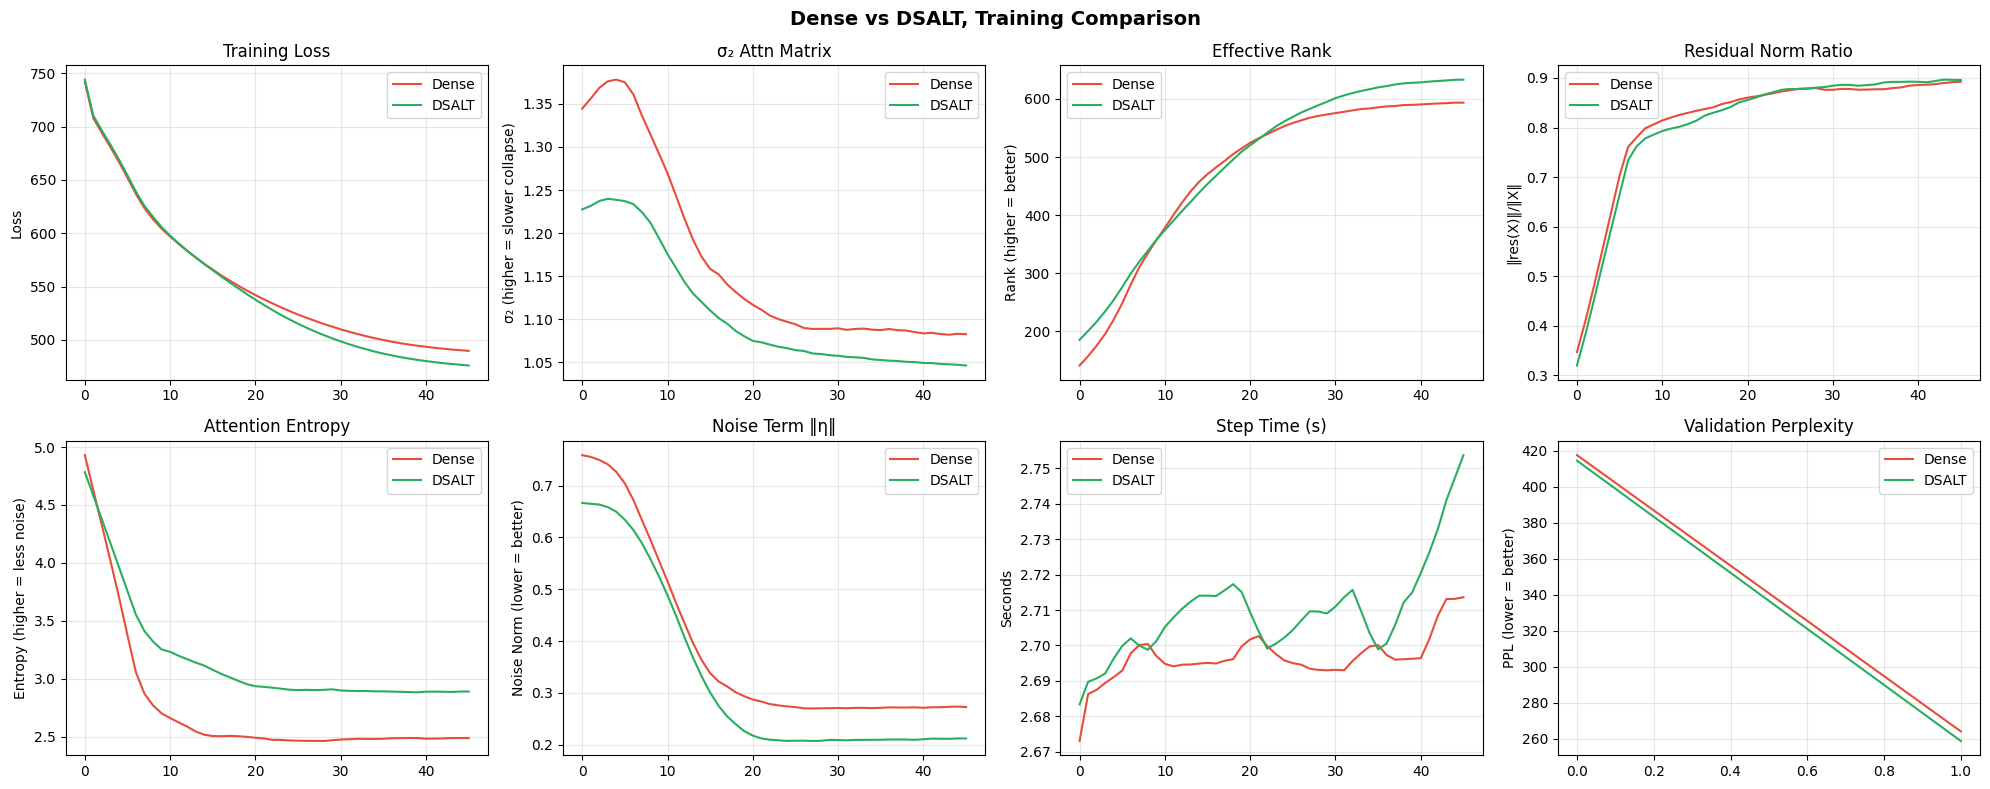

Salvato: comparison.png


In [11]:
def smooth(x, w=10):
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode='valid').tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Dense vs DSALT, Training Comparison", fontsize=14, fontweight='bold')

metrics = [
    ("train_loss",    "Training Loss",        "Loss"),
    ("sigma2",        "σ₂ Attn Matrix",       "σ₂ (higher = slower collapse)"),
    ("eff_rank",      "Effective Rank",        "Rank (higher = better)"),
    ("res_norm",      "Residual Norm Ratio",   "‖res(X)‖/‖X‖"),
    ("attn_entropy",  "Attention Entropy",     "Entropy (higher = less noise)"),
    ("noise_norm",    "Noise Term ‖η‖",        "Noise Norm (lower = better)"),
    ("step_time",     "Step Time (s)",         "Seconds"),
    ("val_ppl",       "Validation Perplexity", "PPL (lower = better)"),
]

for ax, (key, title, ylabel) in zip(axes.flat, metrics):
    d = smooth(dense_history.get(key, []))
    s = smooth(dsalt_history.get(key, []))
    if d: ax.plot(d, label="Dense", color="#e74c3c", linewidth=1.5)
    if s: ax.plot(s, label="DSALT", color="#27ae60", linewidth=1.5)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: comparison.png")

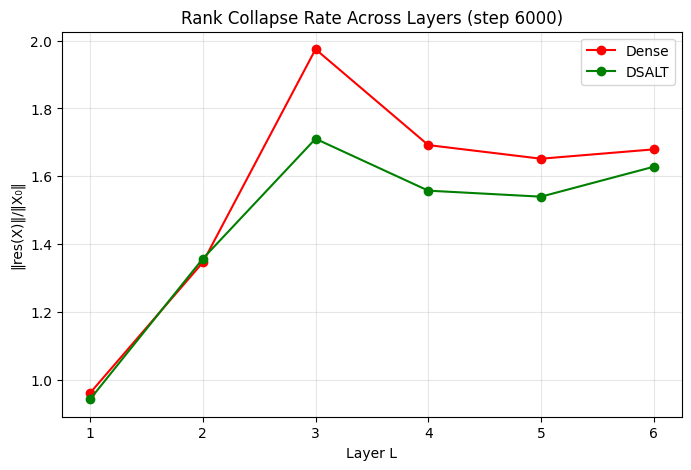

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
d_final = dense_history["layerwise"][-1]
s_final = dsalt_history["layerwise"][-1]
ax.plot(range(1, len(d_final)+1), d_final, 'r-o', label='Dense')
ax.plot(range(1, len(s_final)+1), s_final, 'g-o', label='DSALT')
ax.set_xlabel('Layer L')
ax.set_ylabel('‖res(X)‖/‖X₀‖')
ax.set_title('Rank Collapse Rate Across Layers (step 6000)')
ax.legend()
ax.grid(alpha=0.3)
plt.savefig('layerwise_collapse.png', dpi=150)
plt.show()

In [14]:
long_text = " ".join([tokenizer.decode(train_ds[i][0].tolist()) for i in range(20)])

print("=== Sliding Window PPL ===")
ppl_dense_sw = sliding_window_eval(dense_model, tokenizer, long_text,
                                    CFG["seq_len"], stride=256, device=device)
ppl_dsalt_sw = sliding_window_eval(dsalt_model, tokenizer, long_text,
                                    CFG["seq_len"], stride=256, device=device)

prompt = "The history of artificial intelligence began"
print("\n=== DENSE Generation ===")
print(generate(dense_model, tokenizer, prompt))
print("\n=== DSALT Generation ===")
print(generate(dsalt_model, tokenizer, prompt))

print("\n========== FINAL RESULTS ==========")
_, ppl_dense_val = evaluate(dense_model, val_loader, device)
_, ppl_dsalt_val = evaluate(dsalt_model, val_loader, device)

print(f"{'Metric':<30} {'Dense':>10} {'DSALT':>10}")
print("-" * 52)
print(f"{'Val Perplexity':<30} {ppl_dense_val:>10.2f} {ppl_dsalt_val:>10.2f}")
print(f"{'SW Perplexity (long ctx)':<30} {ppl_dense_sw:>10.2f} {ppl_dsalt_sw:>10.2f}")
print(f"{'Avg σ₂':<30} {np.mean(dense_history['sigma2']):>10.4f} {np.mean(dsalt_history['sigma2']):>10.4f}")
print(f"{'Avg Effective Rank':<30} {np.mean(dense_history['eff_rank']):>10.2f} {np.mean(dsalt_history['eff_rank']):>10.2f}")
print(f"{'Avg Attn Entropy':<30} {np.mean(dense_history['attn_entropy']):>10.4f} {np.mean(dsalt_history['attn_entropy']):>10.4f}")
print(f"{'Avg Noise Norm':<30} {np.mean(dense_history['noise_norm']):>10.4f} {np.mean(dsalt_history['noise_norm']):>10.4f}")
print(f"{'Avg it/s':<30} {np.mean([1/t for t in dense_history['step_time']]):>10.2f} {np.mean([1/t for t in dsalt_history['step_time']]):>10.2f}")

Token indices sequence length is longer than the specified maximum sequence length for this model (20479 > 1024). Running this sequence through the model will result in indexing errors


=== Sliding Window PPL ===
Sliding Window PPL (stride=256): 152.86
Sliding Window PPL (stride=256): 132.97

=== DENSE Generation ===
The history of artificial intelligence began for the city that the city 's borders had been able to an investment , and not at sea with the end of the public sector . 
 = = History = = 
 In the United States was named a report of the Federal Union and United States ( now the primary route of the South America ) , but other storms had little losses and the state at the western state . In the Second World War ( JNR ) was the largest city of the New South Sea , the highest @-@ time warship to build the island . The road has been declared . 
 In the late May 17th and the town was divided under its proximity to the new South Sea of the American colonies , with the First River and the British , the Northern Coast of the East , the New York State . The city of the United States , which formed in the Second and US was built by the U @-@ General of the United Stat